In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,classification_report
from sklearn.ensemble import  RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier 

In [2]:
df=pd.read_csv("D:\\shopping classification datset.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [4]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [5]:
#check null values

In [6]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [7]:
#check outliers

In [8]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


<Axes: xlabel='Administrative_Duration'>

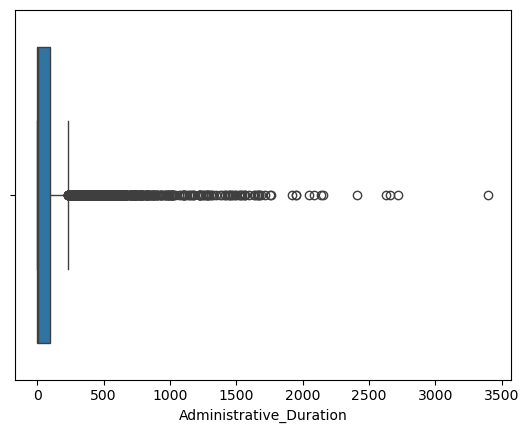

In [9]:
sns.boxplot(x='Administrative_Duration',data=df)

<Axes: xlabel='Informational_Duration'>

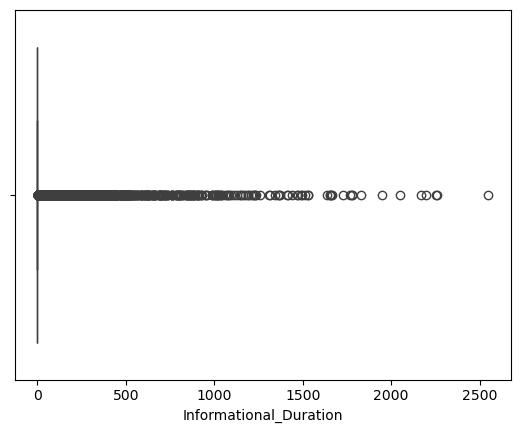

In [10]:
sns.boxplot(x='Informational_Duration',data=df)

<Axes: xlabel='ProductRelated'>

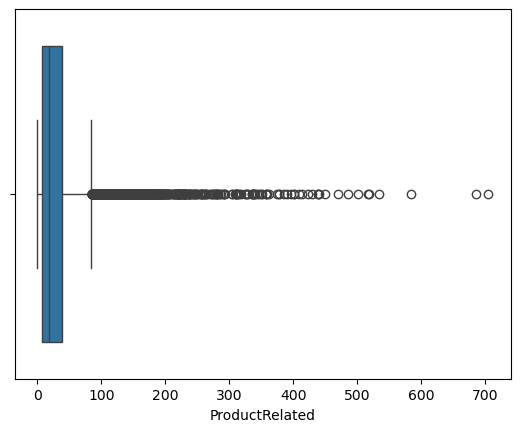

In [11]:
sns.boxplot(x='ProductRelated',data=df)

<Axes: xlabel='ProductRelated_Duration'>

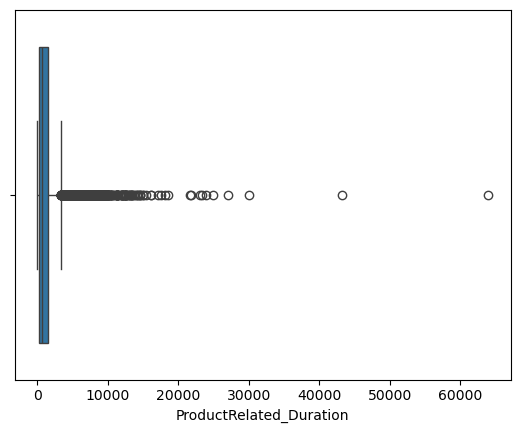

In [12]:
sns.boxplot(x='ProductRelated_Duration',data=df)

<Axes: xlabel='BounceRates'>

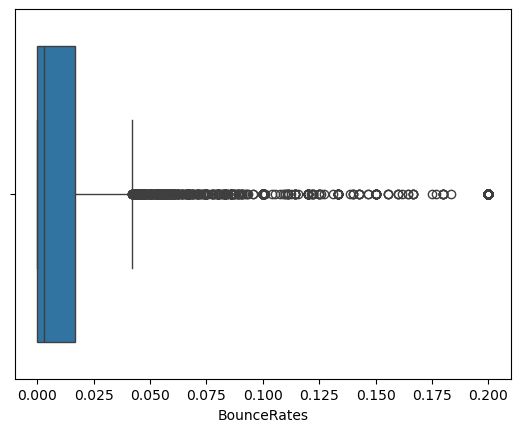

In [13]:
sns.boxplot(x='BounceRates',data=df)

<Axes: xlabel='ExitRates'>

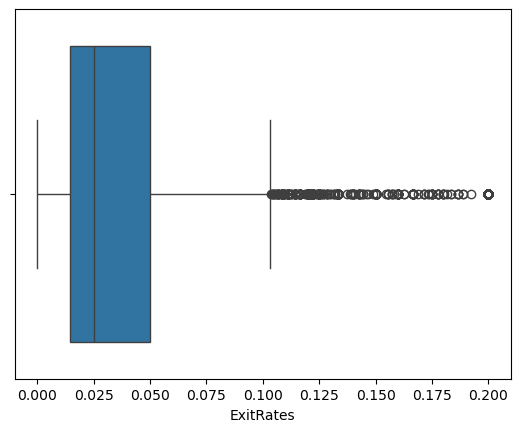

In [14]:
sns.boxplot(x='ExitRates',data=df)

<Axes: xlabel='PageValues'>

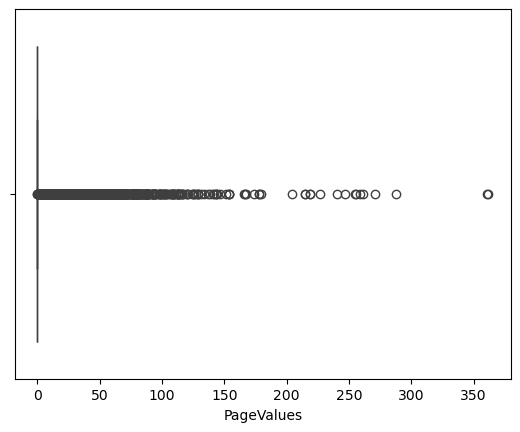

In [15]:
sns.boxplot(x='PageValues',data=df)

<Axes: xlabel='SpecialDay'>

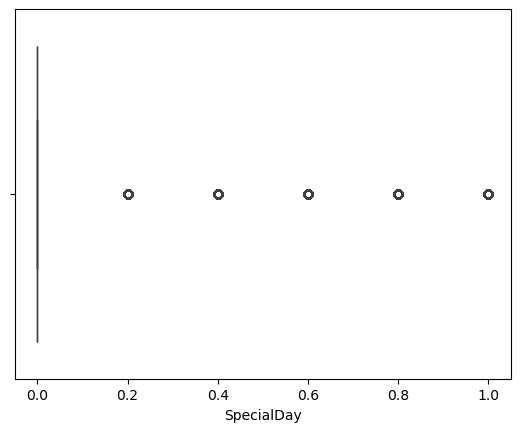

In [16]:
sns.boxplot(x='SpecialDay',data=df)

In [17]:
#feature selection

In [18]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [19]:
import scipy.stats as stats

Revenue_False = df[df['Revenue'] == False]['Administrative']
Revenue_True = df[df['Revenue'] == True]['Administrative']

t_stat, p_value = stats.ttest_ind(Revenue_False, Revenue_True)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("there is relationship")
else:
    print("there is no  relationship")

T-statistic: -15.575193953655198
P-value: 3.5197598377784024e-54
there is relationship


In [20]:
import scipy.stats as stats

Revenue_False = df[df['Revenue'] == False]['Administrative_Duration']
Revenue_True = df[df['Revenue'] == True]['Administrative_Duration']

t_stat, p_value = stats.ttest_ind(Revenue_False, Revenue_True)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("there is relationship")
else:
    print("there is no  relationship")

T-statistic: -10.436882428979533
P-value: 2.1465136347443023e-25
there is relationship


In [21]:
import scipy.stats as stats

Revenue_False = df[df['Revenue'] == False]['Informational']
Revenue_True = df[df['Revenue'] == True]['Informational']

t_stat, p_value = stats.ttest_ind(Revenue_False, Revenue_True)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("there is relationship")
else:
    print("there is no  relationship")

T-statistic: -10.618467075902055
P-value: 3.174034311262581e-26
there is relationship


In [22]:
import scipy.stats as stats

Revenue_False = df[df['Revenue'] == False]['Informational_Duration']
Revenue_True = df[df['Revenue'] == True]['Informational_Duration']

t_stat, p_value = stats.ttest_ind(Revenue_False, Revenue_True)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("there is relationship")
else:
    print("there is no  relationship")

T-statistic: -7.829853965264801
P-value: 5.282870860721484e-15
there is relationship


In [23]:
import scipy.stats as stats

Revenue_False = df[df['Revenue'] == False]['ProductRelated']
Revenue_True = df[df['Revenue'] == True]['ProductRelated']

t_stat, p_value = stats.ttest_ind(Revenue_False, Revenue_True)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("there is relationship")
else:
    print("there is no  relationship")

T-statistic: -17.8281897651485
P-value: 3.2411873289224e-70
there is relationship


In [24]:
import scipy.stats as stats

Revenue_False = df[df['Revenue'] == False]['ProductRelated_Duration']
Revenue_True = df[df['Revenue'] == True]['ProductRelated_Duration']

t_stat, p_value = stats.ttest_ind(Revenue_False, Revenue_True)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("there is relationship")
else:
    print("there is no  relationship")

T-statistic: -17.118049053115055
P-value: 6.1153382534669324e-65
there is relationship


In [25]:
import scipy.stats as stats

Revenue_False = df[df['Revenue'] == False]['BounceRates']
Revenue_True = df[df['Revenue'] == True]['BounceRates']

t_stat, p_value = stats.ttest_ind(Revenue_False, Revenue_True)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("there is relationship")
else:
    print("there is no  relationship")

T-statistic: 16.92263790693806
P-value: 1.59419753851682e-63
there is relationship


In [26]:
import scipy.stats as stats

Revenue_False = df[df['Revenue'] == False]['ExitRates']
Revenue_True = df[df['Revenue'] == True]['ExitRates']

t_stat, p_value = stats.ttest_ind(Revenue_False, Revenue_True)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("there is relationship")
else:
    print("there is no  relationship")

T-statistic: 23.50077662768847
P-value: 1.662653625073804e-119
there is relationship


In [27]:
import scipy.stats as stats

Revenue_False = df[df['Revenue'] == False]['PageValues']
Revenue_True = df[df['Revenue'] == True]['PageValues']

t_stat, p_value = stats.ttest_ind(Revenue_False, Revenue_True)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("there is relationship")
else:
    print("there is no  relationship")

T-statistic: -62.84316160063714
P-value: 0.0
there is relationship


In [28]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Revenue'], df['Month'])


chi2_stat, p_val, dof, expected = chi2_contingency(table)
print( chi2_stat)
print(p_val)

if p_val < 0.05:
    print("there is relationship.")  
else:
    print("There is no relationship") 

384.93476153599426
2.2387855164805443e-77
there is relationship.


In [29]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Revenue'], df['OperatingSystems'])


chi2_stat, p_val, dof, expected = chi2_contingency(table)
print( chi2_stat)
print(p_val)

if p_val < 0.05:
    print("there is relationship.")  
else:
    print("There is no relationship") 

75.02705620298461
1.4160941129614507e-13
there is relationship.


In [30]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Revenue'], df['Browser'])


chi2_stat, p_val, dof, expected = chi2_contingency(table)
print( chi2_stat)
print(p_val)

if p_val < 0.05:
    print("there is relationship.")  
else:
    print("There is no relationship") 

27.715299401381564
0.00608754317955108
there is relationship.


In [31]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Revenue'], df['Region'])


chi2_stat, p_val, dof, expected = chi2_contingency(table)
print( chi2_stat)
print(p_val)

if p_val < 0.05:
    print("there is relationship.")  
else:
    print("There is no relationship") 

9.252751430579844
0.3214249979076556
There is no relationship


In [32]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Revenue'], df['TrafficType'])


chi2_stat, p_val, dof, expected = chi2_contingency(table)
print( chi2_stat)
print(p_val)

if p_val < 0.05:
    print("there is relationship.")  
else:
    print("There is no relationship") 

373.1455646881486
1.652735258160153e-67
there is relationship.


In [33]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Revenue'], df['VisitorType'])


chi2_stat, p_val, dof, expected = chi2_contingency(table)
print( chi2_stat)
print(p_val)

if p_val < 0.05:
    print("there is relationship.")  
else:
    print("There is no relationship") 

135.2519228192047
4.269904152293867e-30
there is relationship.


In [34]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Revenue'], df['Weekend'])


chi2_stat, p_val, dof, expected = chi2_contingency(table)
print( chi2_stat)
print(p_val)

if p_val < 0.05:
    print("there is relationship.")  
else:
    print("There is no relationship") 

10.390978319534856
0.0012663251061221968
there is relationship.


In [35]:
#feature transformation....label encoding and one hot encoding

In [36]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [37]:
hh=LabelEncoder()

In [38]:
df['Weekend']=hh.fit_transform(df['Weekend'])
df['Revenue']=hh.fit_transform(df['Revenue'])

In [39]:
df=pd.get_dummies(df,columns=['Month','VisitorType'],drop_first=True)
df=df.astype(int)
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,0,0,0,0,2,64,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
3,0,0,0,0,2,2,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
4,0,0,0,0,10,627,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145,0,0,53,1783,0,0,12,0,...,0,0,0,0,0,0,0,0,0,1
12326,0,0,0,0,5,465,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
12327,0,0,0,0,6,184,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
12328,4,75,0,0,15,346,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [40]:
df1=df.copy()
df1

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,0,0,0,0,2,64,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
3,0,0,0,0,2,2,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
4,0,0,0,0,10,627,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145,0,0,53,1783,0,0,12,0,...,0,0,0,0,0,0,0,0,0,1
12326,0,0,0,0,5,465,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
12327,0,0,0,0,6,184,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
12328,4,75,0,0,15,346,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [41]:
y=df1['Revenue']
y

0        0
1        0
2        0
3        0
4        0
        ..
12325    0
12326    0
12327    0
12328    0
12329    0
Name: Revenue, Length: 12330, dtype: int64

In [42]:
x=df1.drop(columns='Revenue', axis=1)
x

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,0,0,0,0,2,64,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
3,0,0,0,0,2,2,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
4,0,0,0,0,10,627,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145,0,0,53,1783,0,0,12,0,...,0,0,0,0,0,0,0,0,0,1
12326,0,0,0,0,5,465,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
12327,0,0,0,0,6,184,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
12328,4,75,0,0,15,346,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [43]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [118]:
print(df1['Revenue'].value_counts())

Revenue
0    10422
1     1908
Name: count, dtype: int64


In [83]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(sampling_strategy='minority')
x_sm,y_sm=smote.fit_resample(x_train,y_train)

y_sm.value_counts()

Revenue
0    8367
1    8367
Name: count, dtype: int64

In [45]:
#scaling  standarization

In [84]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [85]:
x_train_scaled

array([[-0.69846932, -0.45625024, -0.39741233, ..., -0.19293516,
        -0.08753091,  0.41092441],
       [-0.09184802, -0.37733568, -0.39741233, ..., -0.19293516,
        -0.08753091,  0.41092441],
       [-0.69846932, -0.45625024, -0.39741233, ..., -0.19293516,
        -0.08753091,  0.41092441],
       ...,
       [-0.69846932, -0.45625024, -0.39741233, ..., -0.19293516,
        -0.08753091,  0.41092441],
       [-0.69846932, -0.45625024, -0.39741233, ..., -0.19293516,
        -0.08753091, -2.4335376 ],
       [ 1.42470521,  0.32162187, -0.39741233, ..., -0.19293516,
        -0.08753091,  0.41092441]], shape=(9864, 26))

In [86]:
x_test_scaled

array([[ 0.21146262,  0.34416889, -0.39741233, ..., -0.19293516,
        -0.08753091,  0.41092441],
       [ 1.12139456,  2.00701146,  1.18135336, ..., -0.19293516,
        -0.08753091,  0.41092441],
       [-0.39515867, -0.22514331, -0.39741233, ..., -0.19293516,
        -0.08753091,  0.41092441],
       ...,
       [-0.69846932, -0.45625024,  1.18135336, ..., -0.19293516,
        -0.08753091,  0.41092441],
       [ 0.21146262, -0.15750226,  3.54950188, ..., -0.19293516,
        -0.08753091,  0.41092441],
       [-0.69846932, -0.45625024, -0.39741233, ..., -0.19293516,
        -0.08753091,  0.41092441]], shape=(2466, 26))

In [49]:
#logestic regression

In [131]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(sampling_strategy='minority')
x_sm,y_sm=smote.fit_resample(x_train,y_train)

y_sm.value_counts()

Revenue
0    8367
1    8367
Name: count, dtype: int64

In [132]:
model1=LogisticRegression()

In [133]:
model1.fit(x_train,y_train)

C:\Users\gayat\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [134]:
y_pred=model1.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 1, 0], shape=(2466,))

In [135]:
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.8673965936739659

In [136]:
## training_accuracy     
y_train_pred=model1.predict(x_train)
final_training=accuracy_score(y_train_pred,y_train)
final_training

0.8830089213300892

In [137]:
## testing_accuracy    
y_pred=model1.predict(x_test)
final_result=accuracy_score(y_test,y_pred)
final_result

0.8673965936739659

In [138]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_sm=scaler.fit_transform(x_sm)
x_test_sm=scaler.transform(x_test)

model_sm=LogisticRegression()
model_sm.fit(x_train_sm,y_sm)
y_cap=model_sm.predict(x_test_sm)

from sklearn.metrics import confusion_matrix,classification_report
sm=classification_report(y_test,y_cap,target_names=['0','1'])
print("\nClassification Report:")
print(sm)


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      2055
           1       0.56      0.54      0.55       411

    accuracy                           0.85      2466
   macro avg       0.74      0.73      0.73      2466
weighted avg       0.85      0.85      0.85      2466



In [57]:
#knn

In [139]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(sampling_strategy='minority')
x_sm,y_sm=smote.fit_resample(x_train,y_train)

y_sm.value_counts()

Revenue
0    8367
1    8367
Name: count, dtype: int64

In [154]:
model2=KNeighborsClassifier()

In [141]:
model2.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [142]:
y_pred=model2.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2466,))

In [143]:
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.8475263584752636

In [144]:
## training_accuracy     
y_train_pred=model2.predict(x_train)
final_training=accuracy_score(y_train_pred,y_train)
final_training

0.8980129764801298

In [145]:
# testing_accuracy    
y_pred=model2.predict(x_test)
final_result=accuracy_score(y_test,y_pred)
final_result

0.8475263584752636

In [146]:
#hyper parameter grid search
from sklearn.model_selection import GridSearchCV  # RandomSearchCV

# Define the model
model2 =KNeighborsClassifier() 

# Define parameter grid
parameter = {'n_neighbors': [3,5,7,9], 'metric': ['euclidean', 'manhattan'] }

# Grid Search
grid = GridSearchCV( estimator=model2, param_grid=parameter, cv=5, scoring='accuracy' )

# Fit using your own training data
grid.fit(x_train, y_train)

# Best parameters
print("Best parameters:", grid.best_params_)

# Best CV score
print("Best CV score:", grid.best_score_)

Best parameters: {'metric': 'euclidean', 'n_neighbors': 5}
Best CV score: 0.8673973901216112


In [155]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_sm=scaler.fit_transform(x_sm)
x_test_sm=scaler.transform(x_test)

model_sm=KNeighborsClassifier()
model_sm.fit(x_train_sm,y_sm)
y_cap=model_sm.predict(x_test_sm)

from sklearn.metrics import confusion_matrix,classification_report
sm=classification_report(y_test,y_cap,target_names=['0','1'])
print("\nClassification Report:")
print(sm)


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      2055
           1       0.50      0.49      0.49       411

    accuracy                           0.83      2466
   macro avg       0.70      0.69      0.70      2466
weighted avg       0.83      0.83      0.83      2466



In [ ]:
#svm

In [156]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(sampling_strategy='minority')
x_sm,y_sm=smote.fit_resample(x_train,y_train)

y_sm.value_counts()

Revenue
0    8367
1    8367
Name: count, dtype: int64

In [157]:
model3=SVC()

In [158]:
model3.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [159]:
y_pred=model3.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2466,))

In [160]:
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.8353609083536091

In [161]:
## training_accuracy     
y_train_pred=model3.predict(x_train)
final_training=accuracy_score(y_train_pred,y_train)
final_training

0.8507704785077048

In [72]:
## testing_accuracy    
y_pred=model3.predict(x_test)
final_result=accuracy_score(y_test,y_pred)
final_result

0.8353609083536091

In [95]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_sm=scaler.fit_transform(x_sm)
x_test_sm=scaler.transform(x_test)

model_sm=SVC()
model_sm.fit(x_train_sm,y_sm)
y_cap=model_sm.predict(x_test_sm)

from sklearn.metrics import confusion_matrix,classification_report
sm=classification_report(y_test,y_cap,target_names=['0','1'])
print("\nClassification Report:")
print(sm)


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      2055
           1       0.59      0.59      0.59       411

    accuracy                           0.86      2466
   macro avg       0.76      0.76      0.76      2466
weighted avg       0.86      0.86      0.86      2466



In [ ]:
#naive bayes

In [96]:
model4=GaussianNB()

In [97]:
model4.fit(x_train,y_train)

,priors,None
,var_smoothing,1e-09


In [98]:
y_pred=model4.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 1, 0], shape=(2466,))

In [99]:
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.813463098134631

In [100]:
## training_accuracy     
y_train_pred=model4.predict(x_train)
final_training=accuracy_score(y_train_pred,y_train)
final_training

0.8218775344687753

In [101]:
## testing_accuracy    
y_pred=model3.predict(x_test)
final_result=accuracy_score(y_test,y_pred)
final_result

0.8353609083536091

In [102]:
scaler=StandardScaler()
x_train_sm=scaler.fit_transform(x_sm)
x_test_sm=scaler.transform(x_test)
model_sm= GaussianNB()
model_sm.fit(x_train_sm,y_sm)
y_cap=model_sm.predict(x_test_sm)

sm = classification_report(y_test, y_cap, target_names=["0", "1"])
print("\nClassification Report:")
print(sm)


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.56      0.70      2055
           1       0.25      0.72      0.37       411

    accuracy                           0.59      2466
   macro avg       0.58      0.64      0.53      2466
weighted avg       0.80      0.59      0.64      2466



In [ ]:
#decision tree

In [103]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,0,0,0,0,2,64,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
3,0,0,0,0,2,2,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
4,0,0,0,0,10,627,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1


In [104]:
y=df1['Revenue']
y

0        0
1        0
2        0
3        0
4        0
        ..
12325    0
12326    0
12327    0
12328    0
12329    0
Name: Revenue, Length: 12330, dtype: int64

In [105]:
x=df1.drop(columns='Revenue', axis=1)
x

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,0,0,0,0,2,64,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
3,0,0,0,0,2,2,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
4,0,0,0,0,10,627,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145,0,0,53,1783,0,0,12,0,...,0,0,0,0,0,0,0,0,0,1
12326,0,0,0,0,5,465,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
12327,0,0,0,0,6,184,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
12328,4,75,0,0,15,346,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [106]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [119]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(sampling_strategy='minority')
x_sm,y_sm=smote.fit_resample(x_train,y_train)

y_sm.value_counts()

Revenue
0    8367
1    8367
Name: count, dtype: int64

In [120]:
model5= DecisionTreeClassifier(max_depth=3,min_samples_leaf=1,min_samples_split=3)
model5.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,3
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [121]:
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.8929440389294404

In [122]:
## training_accuracy     
y_train_pred=model5.predict(x_train)
final_training=accuracy_score(y_train_pred,y_train)
final_training

0.8941605839416058

In [123]:
## testing_accuracy    
y_pred=model5.predict(x_test)
final_result=accuracy_score(y_test,y_pred)
final_result

0.8730738037307381

In [124]:
from sklearn.model_selection import GridSearchCV

# Define model
model5 = DecisionTreeClassifier()

# Parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 6, 7, 3, 10],
    'min_samples_leaf': [1, 2, 3, 4]
}

# Grid Search
grid_search = GridSearchCV(estimator=model5,param_grid=param_grid,cv=5,scoring='accuracy',n_jobs=-1)

# Train model
grid_search.fit(x_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best model
best_model = grid_search.best_estimator_

# Prediction
y_pred = best_model.predict(x_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy: 0.8953771289537713


In [125]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_sm=scaler.fit_transform(x_sm)
x_test_sm=scaler.transform(x_test)

model_sm=DecisionTreeClassifier()
model_sm.fit(x_train_sm,y_sm)
y_cap=model_sm.predict(x_test_sm)

from sklearn.metrics import confusion_matrix,classification_report
sm=classification_report(y_test,y_cap,target_names=['0','1'])
print("\nClassification Report:")
print(sm)


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      2055
           1       0.52      0.56      0.54       411

    accuracy                           0.84      2466
   macro avg       0.71      0.73      0.72      2466
weighted avg       0.85      0.84      0.84      2466



In [126]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=2)

xgb.fit(x_train, y_train)
y_pred = xgb.predict(x_test)

print("XGBoost Test Accuracy:", accuracy_score(y_test, y_pred))

XGBoost Test Accuracy: 0.8929440389294404


In [127]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_sm=scaler.fit_transform(x_sm)
x_test_sm=scaler.transform(x_test)

model_sm= XGBClassifier()
model_sm.fit(x_train_sm,y_sm)
y_cap=model_sm.predict(x_test_sm)

from sklearn.metrics import confusion_matrix,classification_report
sm=classification_report(y_test,y_cap,target_names=['0','1'])
print("\nClassification Report:")
print(sm)


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      2055
           1       0.64      0.65      0.65       411

    accuracy                           0.88      2466
   macro avg       0.78      0.79      0.79      2466
weighted avg       0.88      0.88      0.88      2466



In [130]:
from sklearn.metrics import confusion_matrix,classification_report
r=classification_report(y_test,y_pred,target_names=['0','1'])
print("\nClassification Report:")
print(r)


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2055
           1       0.72      0.58      0.64       411

    accuracy                           0.89      2466
   macro avg       0.82      0.77      0.79      2466
weighted avg       0.89      0.89      0.89      2466

